In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import plotting, image, datasets

BASE_DIR = r"C:\Users\user\OneDrive\Desktop\bouns\TASK.DATA\TASK.DATA"
ANAT_PATH = os.path.join(BASE_DIR, 'anat', 'sub-10225_T1w.nii')
FUNC_PATH = os.path.join(BASE_DIR, 'func', 'sub-10225_task-stopsignal_bold.nii')

# چک کردن فایل‌ها
if os.path.exists(ANAT_PATH) and os.path.exists(FUNC_PATH):
    print("✅ Files found ready to start.")
else:
    print("❌ Error: Check your paths!")
    
anat_img = nib.load(ANAT_PATH)
func_img = nib.load(FUNC_PATH)

print(f"   Anatomical Shape: {anat_img.shape}")
print(f"   Functional Shape: {func_img.shape}")


✅ Files found ready to start.
   Anatomical Shape: (176, 256, 256)
   Functional Shape: (64, 64, 34, 184)


C:\Users\user\AppData\Local\Temp\ipykernel_11016\1407891924.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_func_img = image.mean_img(func_img)


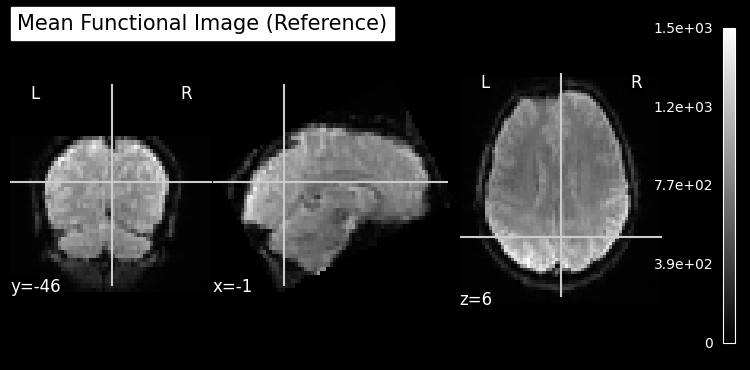

In [2]:
#Motion Correction & Slice Timing (

mean_func_img = image.mean_img(func_img)

plotting.plot_epi(mean_func_img, title='Mean Functional Image (Reference)')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_11016\1699131302.py:5: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  normalized_anat = image.resample_to_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1699131302.py:5: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  normalized_anat = image.resample_to_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1699131302.py:12: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  normalized_func = image.resample_to_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1699131302.py:12: FutureWarning: From release 0.13.0 onwards, this function will, by defau

   New Anat Shape (MNI): (197, 233, 189)
   New Func Shape (MNI): (197, 233, 189, 184)


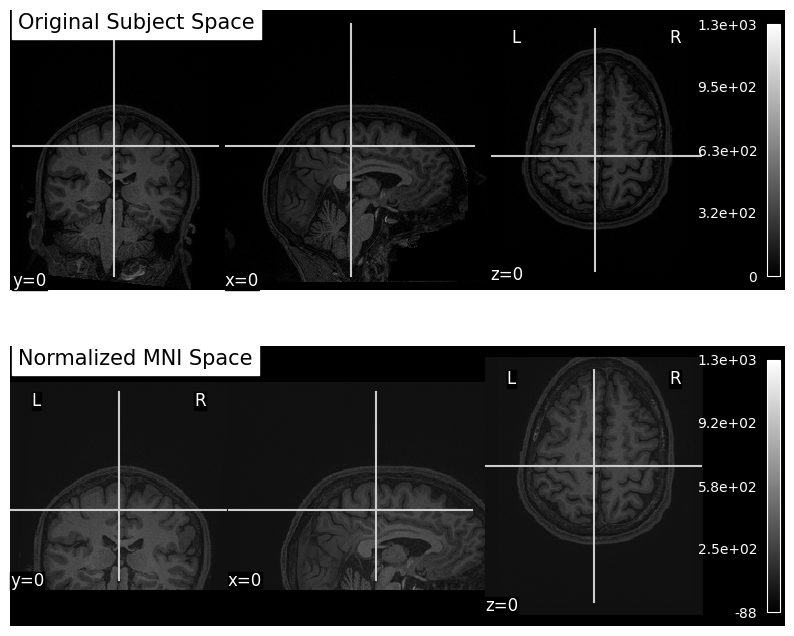

In [3]:
#Normalization 


mni_template = datasets.load_mni152_template()
normalized_anat = image.resample_to_img(
    source_img=anat_img,
    target_img=mni_template,
    interpolation='continuous' # برای آناتومی کیفیت بالا می‌خواهیم
)


normalized_func = image.resample_to_img(
    source_img=func_img,
    target_img=mni_template,
    interpolation='nearest' # برای فانکشنال معمولاً سریع‌تر است
)


print(f"   New Anat Shape (MNI): {normalized_anat.shape}")
print(f"   New Func Shape (MNI): {normalized_func.shape}")


fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plotting.plot_anat(anat_img, title="Original Subject Space", axes=ax[0], cut_coords=(0, 0, 0))
plotting.plot_anat(normalized_anat, title="Normalized MNI Space", axes=ax[1], cut_coords=(0, 0, 0))
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_11016\1547430928.py:7: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  normalized_anat = image.resample_to_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1547430928.py:7: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  normalized_anat = image.resample_to_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1547430928.py:14: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  normalized_func = image.resample_img(
C:\Users\user\AppData\Local\Temp\ipykernel_11016\1547430928.py:14: FutureWarning: From release 0.13.0 onwards, this function will, by default,

   Original Func Shape: (64, 64, 34, 184)
   New Func Shape (3mm MNI): (64, 78, 70, 184)


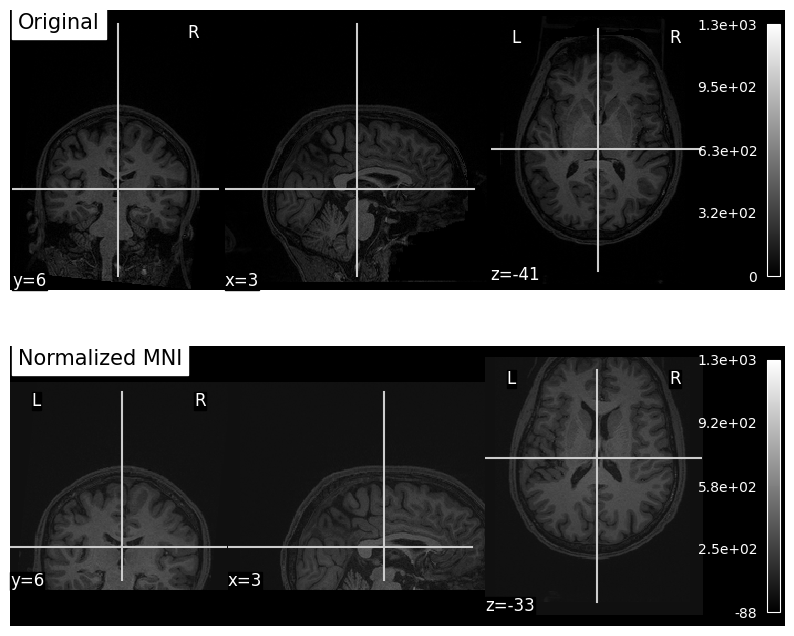

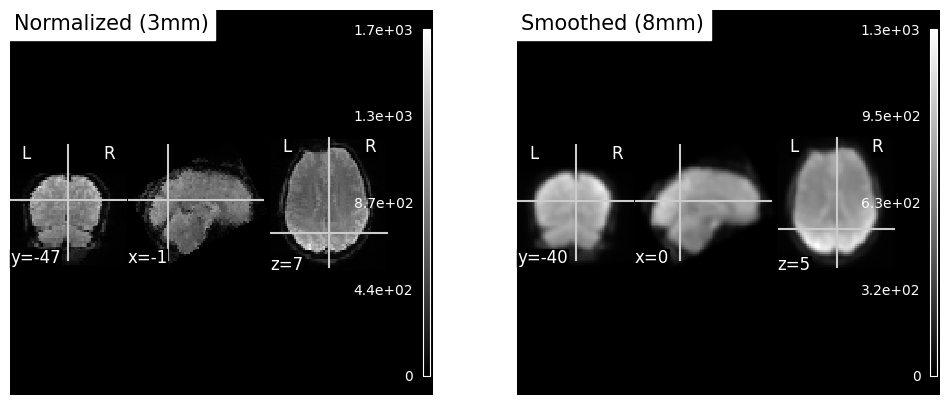

In [6]:
#Smoothing


mni_template = datasets.load_mni152_template()
target_affine = np.diag([3, 3, 3]) 

normalized_anat = image.resample_to_img(
    source_img=anat_img,
    target_img=mni_template,
    interpolation='continuous'
)


normalized_func = image.resample_img(
    img=func_img,
    target_affine=target_affine,           
    target_shape=None,                      
    interpolation='nearest'
)

print(f"   Original Func Shape: {func_img.shape}")
print(f"   New Func Shape (3mm MNI): {normalized_func.shape}") 

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plotting.plot_anat(anat_img, title="Original", axes=ax[0])
plotting.plot_anat(normalized_anat, title="Normalized MNI", axes=ax[1])
plt.show()



smoothed_func = image.smooth_img(normalized_func, fwhm=8)

# ذخیره
output_dir = os.path.join(BASE_DIR, 'preprocessed_output')
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'sub-10225_task-sst_space-MNI_desc-smooth_bold.nii.gz')
smoothed_func.to_filename(save_path)


# نمایش مقایسه
first_vol_raw = image.index_img(normalized_func, 0)
first_vol_smooth = image.index_img(smoothed_func, 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plotting.plot_epi(first_vol_raw, title="Normalized (3mm)", axes=ax[0])
plotting.plot_epi(first_vol_smooth, title="Smoothed (8mm)", axes=ax[1])
plt.show()


